# preprocessing

In [114]:
import pandas as pd
import json

In [115]:
datasets_paths = {
    "linkedin": "../extractor/linkedin_translated_skills.jsonl",
    "alljobs": "../extractor/alljobs_translated_skills.jsonl"
}

In [116]:
def clean_skill_data(item):
    """Extracts and cleans skills from the nested JSON structure."""
    all_matches = item['skills'].get('full_matches', []) + item['skills'].get('ngram_matches', [])
    skills = [m['doc_node_value'].lower() for m in all_matches]
    
    noise = ['com', 'job description', 'product name', 'brand names']
    clean = [s for s in skills if len(s) > 2 and s not in noise]
    return list(set(clean))

In [117]:
def process_dataset_file(dataset_source, dataset_path):
    processed_records = []
    with open(dataset_path, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                item = json.loads(line)
                title = item.get('title', 'Unknown Title')
                query_title = item.get('og_title')

                # scarping typo
                if not query_title:
                    query_title = item.get('og_tite')
                    
                skills = clean_skill_data(item)
                if skills:
                    processed_records.append({
                    'query_title': query_title,
                    'title': title,
                    'skills': skills,
                    'source': dataset_source
                })
            except json.JSONDecodeError:
                continue


    return pd.DataFrame(processed_records)

In [118]:
datasets_dfs = []
for dataset_source, dataset_file in datasets_paths.items():
    datasets_dfs.append(process_dataset_file(dataset_source, dataset_file))

df = pd.concat(datasets_dfs, ignore_index=True)

In [119]:
df.head()

,query_title,title,skills,source
0,SOC Analyst,SOC Analyst Tier 2 (1005527),"[researching, technical writing, innovative, e...",linkedin
1,SOC Analyst,Security Operations Center Analyst,"[monitor events, banking, consultancy, cyber s...",linkedin
2,SOC Analyst,SOC Analyst,"[privilege escalation, scripting, persistence,...",linkedin
3,SOC Analyst,Soc Analyst,"[firewall, web application, cyber threats, cyb...",linkedin
4,SOC Analyst,Security Operations Center Analyst,[splunk],linkedin


In [120]:
df.shape

(8486, 4)

In [121]:
print(df.describe)

<bound method NDFrame.describe of                                    query_title  \
0                                  SOC Analyst   
1                                  SOC Analyst   
2                                  SOC Analyst   
3                                  SOC Analyst   
4                                  SOC Analyst   
...                                        ...   
8481  Security Researcher (Mobile/Android/iOS)   
8482  Security Researcher (Mobile/Android/iOS)   
8483  Security Researcher (Mobile/Android/iOS)   
8484  Security Researcher (Mobile/Android/iOS)   
8485  Security Researcher (Mobile/Android/iOS)   

                                         title  \
0                 SOC Analyst Tier 2 (1005527)   
1           Security Operations Center Analyst   
2                                  SOC Analyst   
3                                  Soc Analyst   
4           Security Operations Center Analyst   
...                                        ...   
8481  לארגון פי

In [122]:
df["title"].unique()

<StringArray>
[                                                   'SOC Analyst Tier 2 (1005527)',
                                              'Security Operations Center Analyst',
                                                                     'SOC Analyst',
                                                                     'Soc Analyst',
                          '🔐 SOC Analyst – Tier 2 | Enterprise Environment (5359)',
                                                              'SOC Analyst Tier 2',
                                          'Incident Response &amp; Threat Hunting',
                                                            'SOC Analyst Tier 2 ל',
                                                       'Cybersecurity SOC Analyst',
 'Cybersecurity Specialist - Entry Level Career Path Leading to Future Employment',
 ...
                                                                   'IT Technician',
                                           'CX Manager - 

In [123]:
df['title'].value_counts()

title
DevOps Engineer                             114
Product Manager                              95
Senior Backend Developer                     84
Data Engineer                                66
Software Engineer                            66
                                           ... 
משרת סטודנט - פיתוח תוכנה - מובייל ו AR       1
לארגון פיננסי במרכז דרוש /ה מפתח /ת IOS!      1
מנתח /ת מערכות דיגיטל                         1
דרוש /ה מפתח /ת אפליקציות Native IOS          1
Mobile Growth Account Manager                 1
Name: count, Length: 4727, dtype: int64

# EDA

In [124]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [125]:
POC_TITLES = ['Software Engineer', 'Data Scientist', 'Product Manager', 'DevOps Engineer', 'Frontend Developer']

# Filter by query_title (og_title) — captures ALL postings for each role,
# not just the ones with an exact title match
sample_df = df[df["query_title"].isin(POC_TITLES)].copy()

print(f"sample_df: {len(sample_df)} records across {sample_df['query_title'].nunique()} roles")
print(sample_df["query_title"].value_counts())

sample_df: 1336 records across 5 roles
query_title
Software Engineer     619
Product Manager       330
Data Scientist        166
Frontend Developer    123
DevOps Engineer        98
Name: count, dtype: int64


In [126]:
sample_df.shape

(1336, 4)

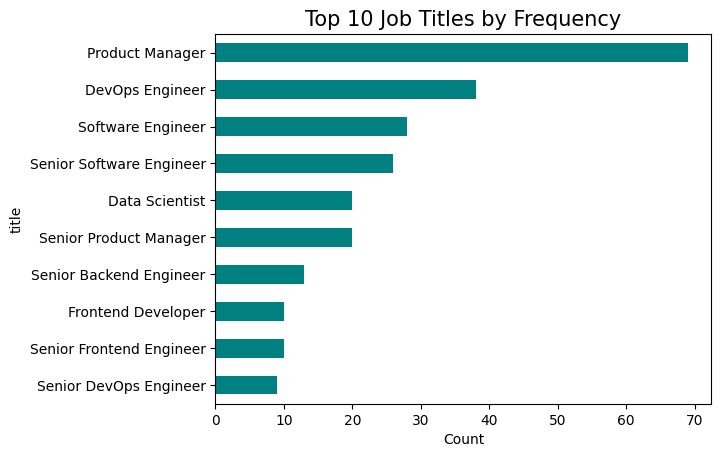

In [127]:
plt.figure()
sample_df['title'].value_counts().head(10).plot(kind='barh', color='teal')
plt.title('Top 10 Job Titles by Frequency', fontsize=15)
plt.xlabel('Count')
plt.gca().invert_yaxis() # Highest on top
plt.show()

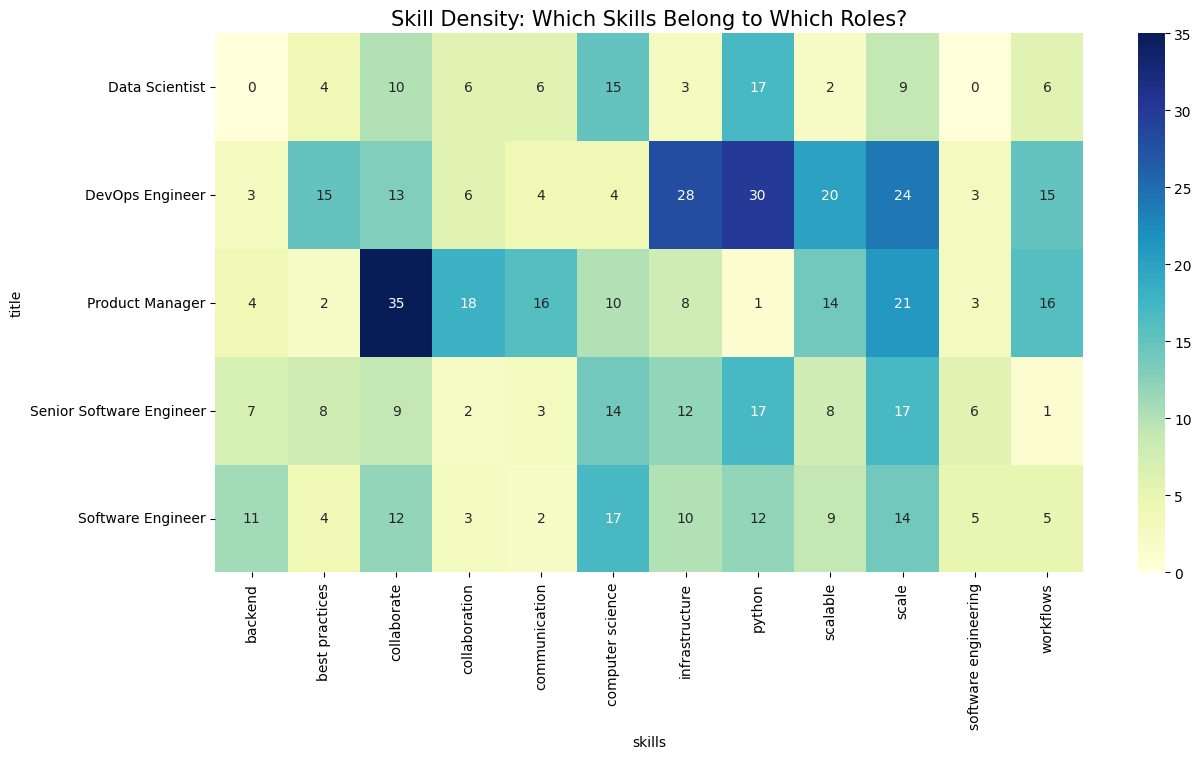

In [128]:
df_exploded = sample_df.explode('skills')
top_titles = sample_df['title'].value_counts().nlargest(5).index
top_skills = df_exploded['skills'].value_counts().nlargest(12).index

# Filter and create frequency table
heatmap_data = df_exploded[
    df_exploded['title'].isin(top_titles) & 
    df_exploded['skills'].isin(top_skills)
]
pivot_table = heatmap_data.pivot_table(index='title', columns='skills', aggfunc='size', fill_value=0)

plt.figure(figsize=(14, 7))
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Skill Density: Which Skills Belong to Which Roles?', fontsize=15)
plt.show()

In [129]:
def plot_skill_rank_for_title(df, target_title, min_appearance=2):
    """
    Plots the most frequent skills for a canonical role (query_title),
    showing both raw frequency and prevalence % across postings.
    """
    # Filter by query_title — covers all posting variants for this role
    subset = df[df['query_title'].str.lower() == target_title.lower()]

    if subset.empty:
        print(f"No data found for role: {target_title}")
        return

    total_postings = len(subset)
    all_skills = [skill for sublist in subset['skills'] for skill in sublist]
    skill_counts = Counter(all_skills)

    rank_df = pd.DataFrame(skill_counts.items(), columns=['Skill', 'Frequency'])
    rank_df['Prevalence'] = (rank_df['Frequency'] / total_postings * 100).round(1)
    rank_df = rank_df[rank_df['Frequency'] >= min_appearance]
    rank_df = rank_df.sort_values(by='Frequency', ascending=False).head(20)

    if rank_df.empty:
        print(f"No skills meet the minimum frequency of {min_appearance} for {target_title}")
        return

    fig, ax = plt.subplots(figsize=(10, len(rank_df) * 0.45))
    bars = ax.barh(rank_df['Skill'], rank_df['Frequency'], color='steelblue')

    # Annotate with prevalence %
    for bar, pct in zip(bars, rank_df['Prevalence']):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f'{pct}%', va='center', fontsize=9, color='dimgray')

    ax.invert_yaxis()
    ax.set_title(f'Top Skills: {target_title}\n({total_postings} postings)', fontsize=14)
    ax.set_xlabel('Times Appeared')
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

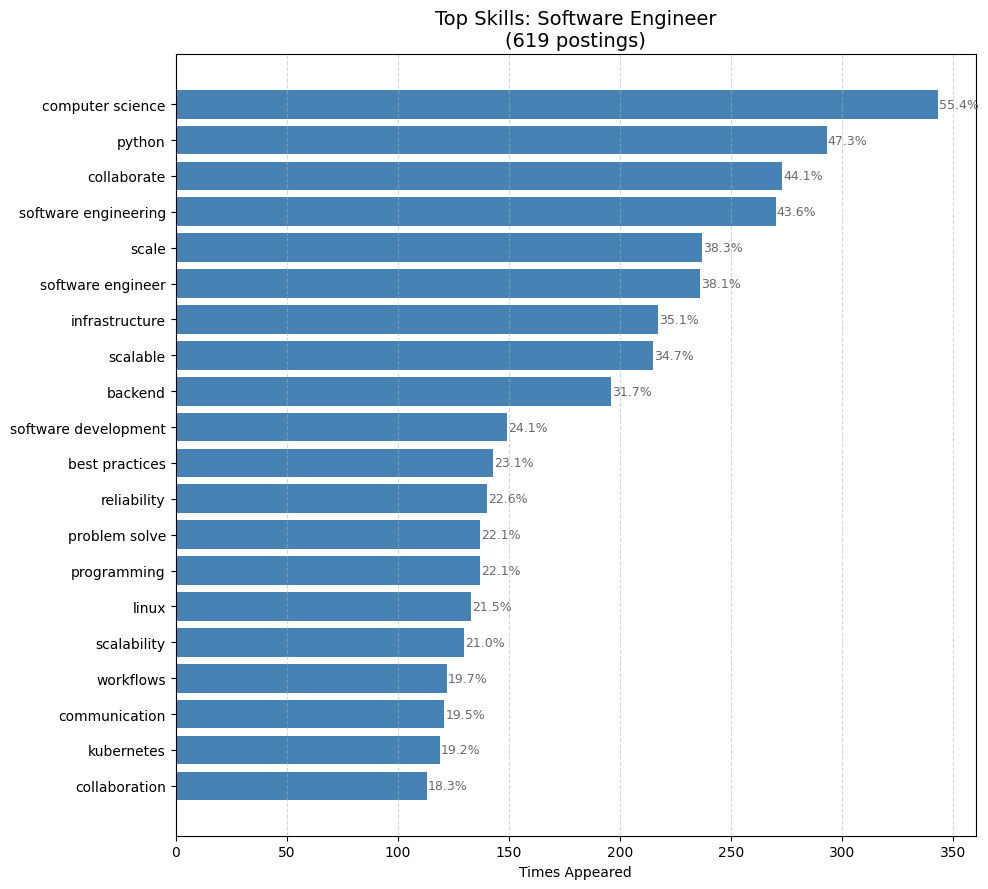

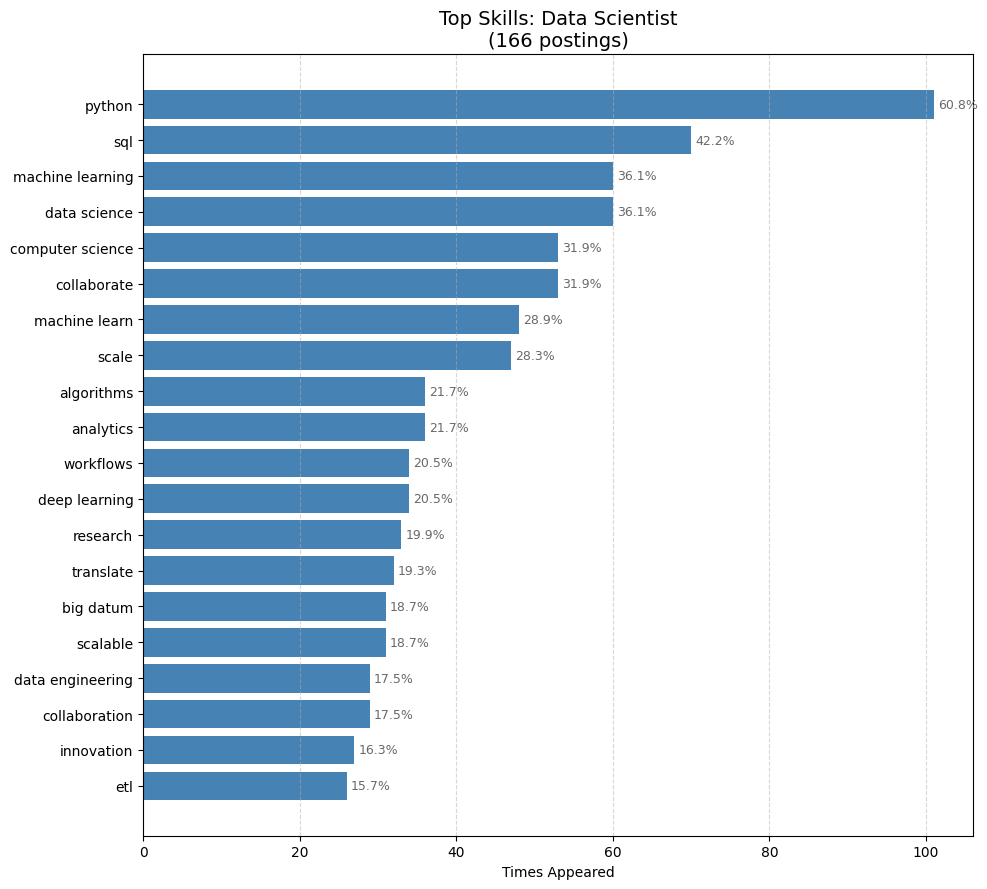

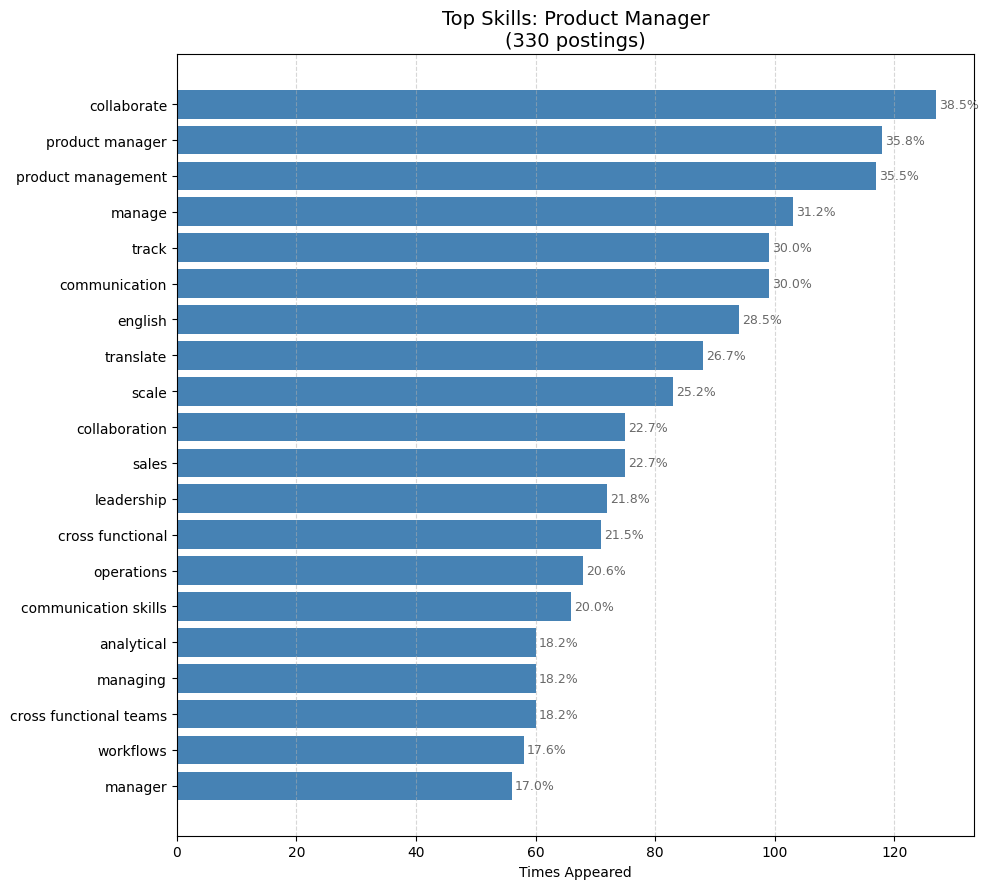

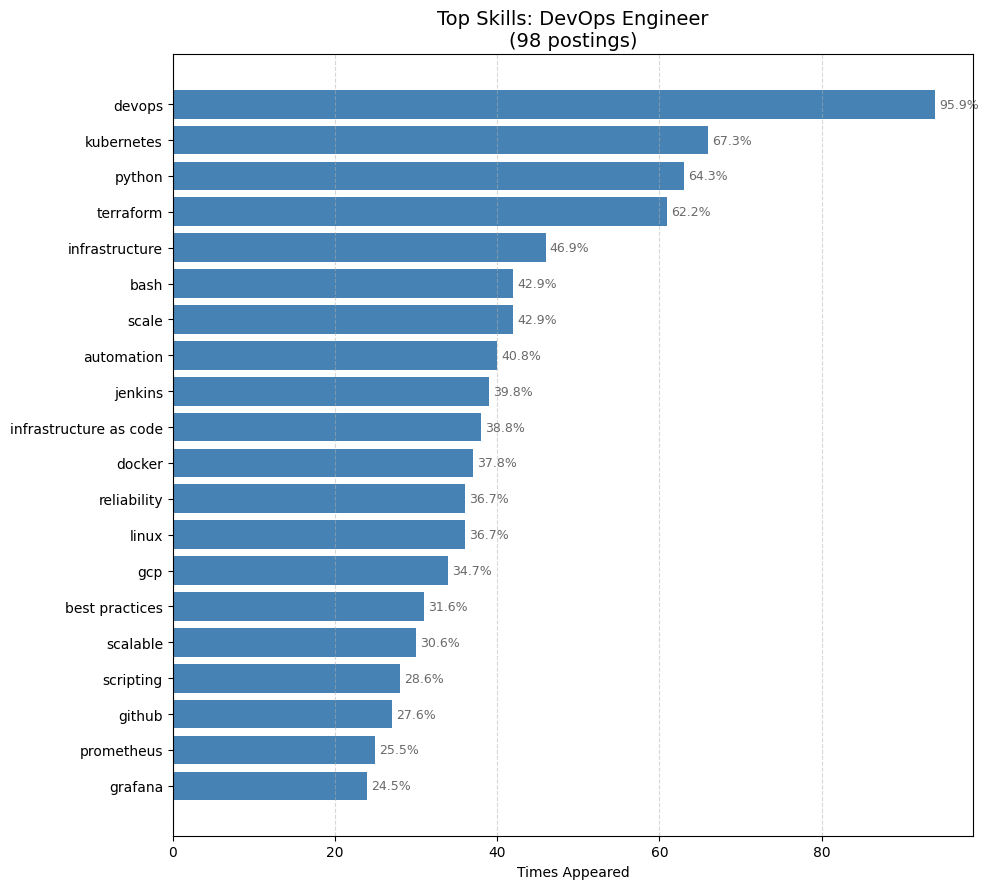

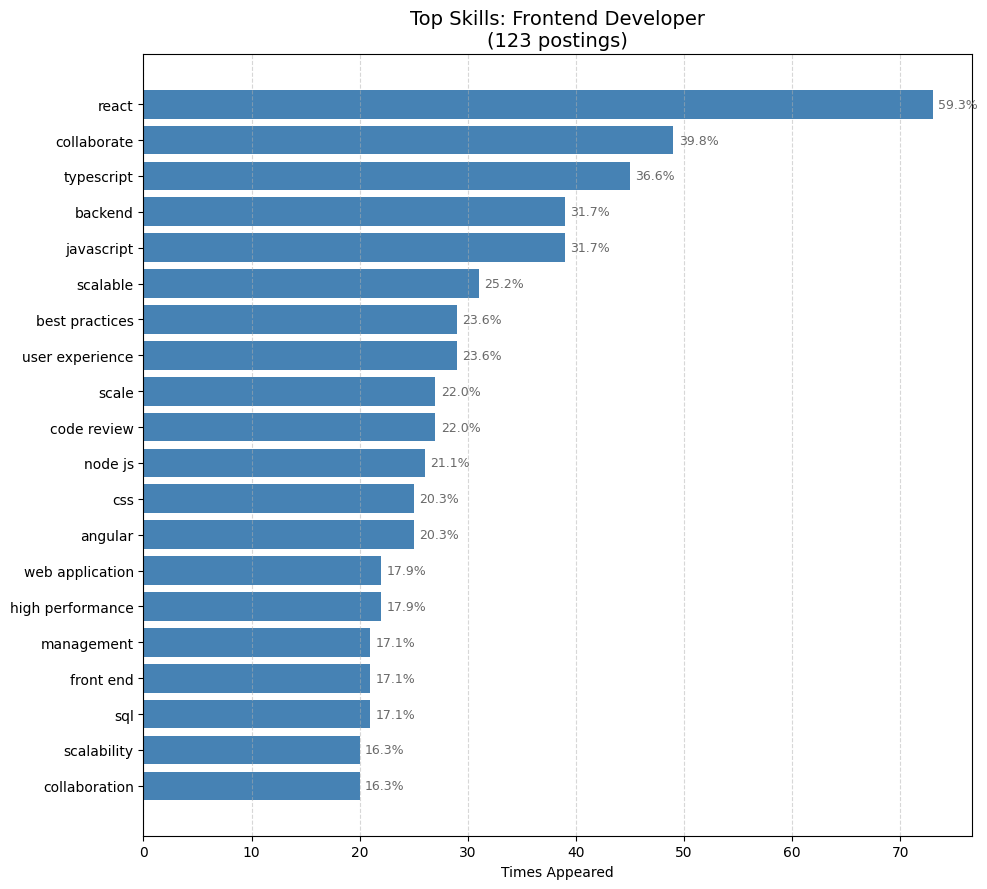

In [130]:
for title in POC_TITLES:
    plot_skill_rank_for_title(sample_df, title)

In [131]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

sample_titles = [
    "Senior Data Analyst",
    "Security Analyst",
    "Product Manager"
]

# Character N-Grams — fixes 'scale/scalable' fuzzy matching issues
tfidf = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 4))
X = tfidf.fit_transform(sample_titles)

feature_names = tfidf.get_feature_names_out()
vector_df = pd.DataFrame(X.toarray(), columns=feature_names, index=sample_titles)

print("Top Feature Chunks for 'Senior Data Analyst':")
print(vector_df.loc[["Senior Data Analyst"]].T.sort_values(by="Senior Data Analyst", ascending=False).head(10))

Top Feature Chunks for 'Senior Data Analyst':
      Senior Data Analyst
 dat              0.20053
 da               0.20053
ior               0.20053
ata               0.20053
ata               0.20053
 sen              0.20053
ior               0.20053
nio               0.20053
ta                0.20053
sen               0.20053


C:\Users\may20\AppData\Local\Temp\ipykernel_72632\3055616974.py:37: UserWarning: Glyph 128272 (\N{CLOSED LOCK WITH KEY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\may20\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128272 (\N{CLOSED LOCK WITH KEY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


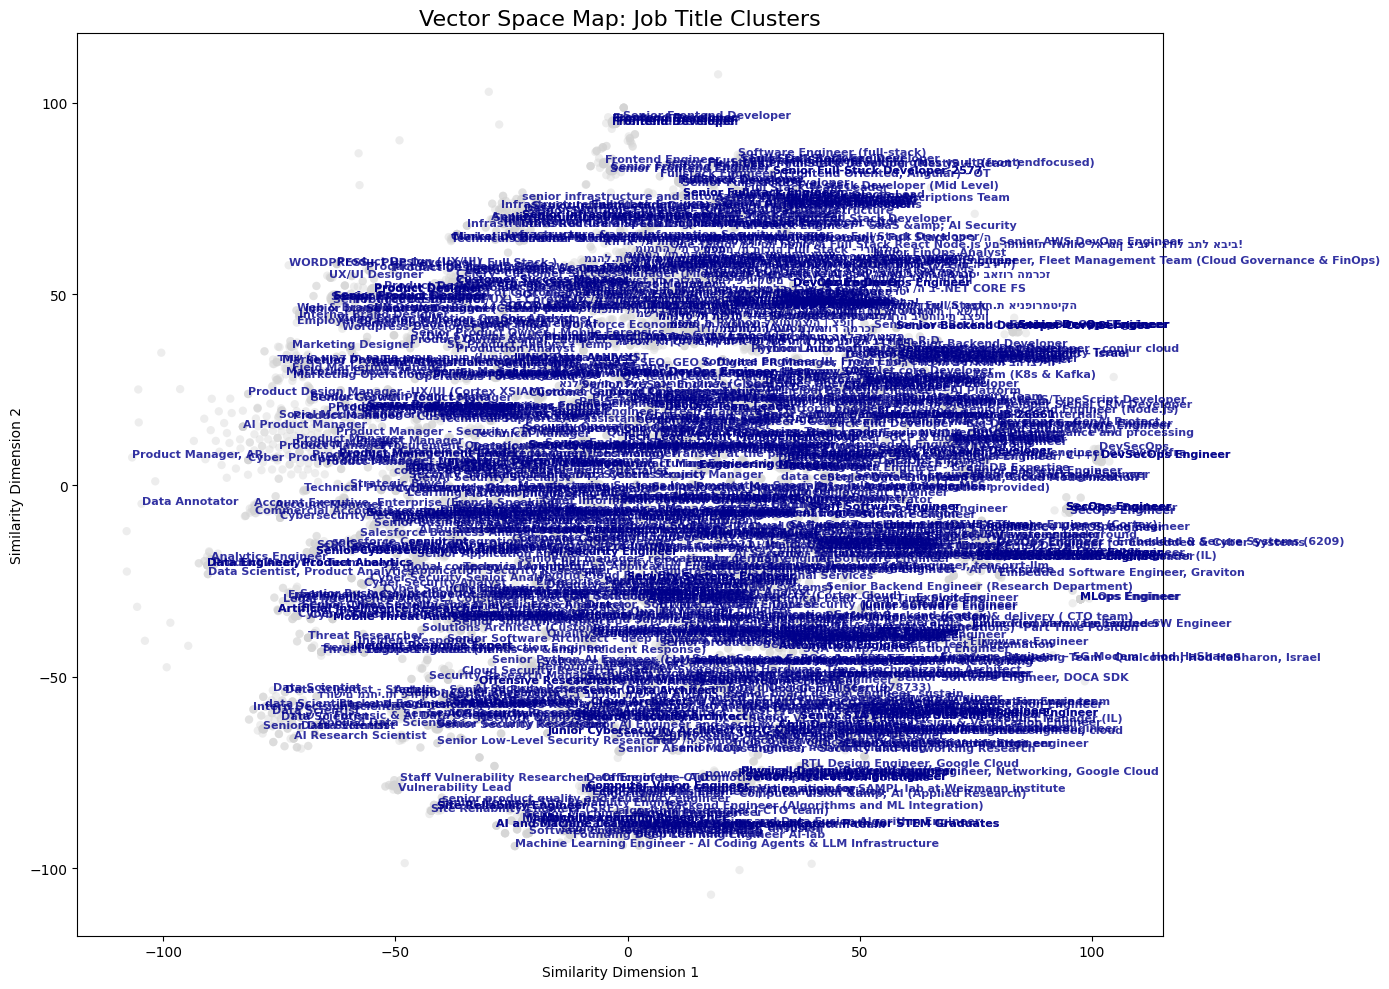

In [132]:
from sklearn.manifold import TSNE
from sklearn.feature_extraction.text import TfidfVectorizer 
import matplotlib.pyplot as plt
import numpy as np

tfidf = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 4))
# 1. Vectorize the titles
X_full = tfidf.fit_transform(df['title'])

# 2. Run t-SNE
# Perplexity should be smaller than the number of samples
tsne = TSNE(n_components=2, perplexity=min(30, len(df)-1), random_state=42)
X_embedded = tsne.fit_transform(X_full.toarray())

# 3. Plotting
plt.figure(figsize=(14, 10))
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], alpha=0.4, c='lightgrey', edgecolors='none')

# 4. Adding Labels (The "Magic" part)
# To avoid a mess, we will label a subset of points
# You can change this to label every 5th point, or just the top 20 points
for i in range(len(df)):
    # Example logic: label every 5th title to keep it clean
    if i % 10 == 0:
        plt.annotate(
            df['title'].iloc[i], 
            (X_embedded[i, 0], X_embedded[i, 1]),
            fontsize=8,
            alpha=0.8,
            color='darkblue',
            weight='semibold'
        )

plt.title("Vector Space Map: Job Title Clusters", fontsize=16)
plt.xlabel("Similarity Dimension 1")
plt.ylabel("Similarity Dimension 2")
plt.tight_layout()
plt.show()

In [133]:
import plotly.express as px
import webbrowser, os

plot_df = pd.DataFrame({
    'x': X_embedded[:, 0],
    'y': X_embedded[:, 1],
    'title': df['title']
})

fig = px.scatter(plot_df, x='x', y='y', hover_name='title',
                width=1200, height=1000,
                title="Interactive Job Title Map (Hover to see titles)")

out = r'c:\Git\CareerLens\ds\model\tsne_map.html'
fig.write_html(out)
webbrowser.open(f'file:///{out}')
print(f"Saved to {out}")

Saved to c:\Git\CareerLens\ds\model\tsne_map.html


# Train

In [ ]:
# ── Training is now managed by train.py ──────────────────────────────────────
# Run from the project root:  python ds/model/train.py
#
# train.py uses CANONICAL_TITLE_VARIANTS (59 titles) and is the source of truth.
# The cells below are kept for reference / EDA only.
# DO NOT run the cells below to produce the final model.joblib — use train.py.
#
# To retrain:
#   python ds/model/train.py
# Output:
#   ds/model/model.joblib          ← loaded by server.py
#   ds/model/canonical_titles.json ← loaded by server.py
print("Training is managed by ds/model/train.py — run that script to retrain the model.")

In [ ]:
import numpy as np

def compute_feature_matrix(
    role_skill_scores: dict,
    role_skill_counts: dict,
    record_counts: dict,
) -> dict:
    all_titles = list(role_skill_scores.keys())
    n_titles   = len(all_titles)

    # IDF: how many titles contain each skill
    skill_title_count = defaultdict(int)
    for skills in role_skill_scores.values():
        for skill in skills:
            skill_title_count[skill] += 1

    feature_matrix = {}
    for title in all_titles:
        n = record_counts[title]
        if n == 0:
            continue
        feature_matrix[title] = {}
        for skill, total_score in role_skill_scores[title].items():
            frequency         = role_skill_counts[title][skill]
            prevalence        = total_score / n  # weighted — identical to current model sort key

            idf               = np.log(n_titles / skill_title_count[skill]) if skill_title_count[skill] > 0 else 0
            title_specificity = idf / np.log(max(n_titles, 2))

            feature_matrix[title][skill] = {
                'frequency':         frequency,
                'prevalence':        prevalence,
                'title_specificity': float(np.clip(title_specificity, 0.0, 1.0)),
            }

    # Normalize prevalence to [0,1] per title (most common skill = 1.0)
    for title in feature_matrix:
        max_prev = max(f['prevalence'] for f in feature_matrix[title].values())
        if max_prev > 0:
            for skill in feature_matrix[title]:
                feature_matrix[title][skill]['prevalence'] /= max_prev

    return feature_matrix

feature_matrix = compute_feature_matrix(role_skill_scores, role_skill_counts, record_counts)

# Sanity check
sample_title = 'Software Engineer'
sample_skill = list(feature_matrix[sample_title].keys())[0]
print(f"Sample: ({sample_title}, {sample_skill})")
print(feature_matrix[sample_title][sample_skill])
print(f"\nFeature matrix stats:")
for title in POC_TITLES:
    n_skills = len(feature_matrix.get(title, {}))
    print(f"  {title}: {n_skills} skills")

# DS-8: Canonical Title Set

In [ ]:
# DS-8: Analyze which query_titles have enough records to be canonical
# Run this cell and report the output — it determines CANONICAL_TITLE_VARIANTS below.

title_counts = df['query_title'].value_counts()
eligible     = title_counts[title_counts >= 20].sort_values(ascending=False)

def confidence_level(n: int) -> str:
    if n >= 100: return 'high'
    if n >= 50:  return 'medium'
    return 'low'

print(f"Eligible titles (≥20 records): {len(eligible)}\n")
for title, count in eligible.items():
    marker = '★' if title in POC_TITLES else ' '
    print(f"  {marker} [{confidence_level(count):6}] {count:4}  {title}")

In [ ]:
# DS-8: After reviewing the output above, fill in CANONICAL_TITLE_VARIANTS.
# ⚠️  Run the analysis cell first, then expand this dict with the eligible titles.
# The 5 POC titles must remain exactly as-is.

CANONICAL_TITLE_VARIANTS = {
    # ── Original 5 POC titles (unchanged) ────────────────────────────────────
    "Software Engineer": [
        "Software Engineer", "Senior Software Engineer", "Backend Engineer",
        "Senior Backend Engineer", "Backend Software Engineer", "Full Stack Engineer",
        "Senior Full Stack Engineer", "SW Engineer", "Senior SW Engineer",
        "Junior Software Engineer", "Python Developer",
    ],
    "Data Scientist": [
        "Data Scientist", "Senior Data Scientist",
    ],
    "Product Manager": [
        "Product Manager", "Senior Product Manager", "Group Product Manager",
        "Product Owner", "Technical Product Manager", "Associate Product Manager",
    ],
    "DevOps Engineer": [
        "DevOps Engineer", "Senior DevOps Engineer", "Cloud Engineer",
        "Site Reliability Engineer", "SRE", "Infrastructure Engineer",
        "Azure DevOps Engineer", "Junior DevOps Engineer",
    ],
    "Frontend Developer": [
        "Frontend Developer", "Senior Frontend Developer", "Frontend Engineer",
        "Senior Frontend Engineer", "React Developer", "UI Developer",
        "UI Engineer", "Web Developer",
    ],
    # ── New titles (fill after running the analysis cell above) ──────────────
    # "Data Engineer": ["Data Engineer", "Senior Data Engineer", ...],
    # "QA Engineer":   ["QA Engineer", "Quality Assurance Engineer", ...],
    # ...
}

CANONICAL_TITLES = list(CANONICAL_TITLE_VARIANTS.keys())

VARIANT_TO_CANONICAL_EXPANDED = {
    variant.lower(): canonical
    for canonical, variants in CANONICAL_TITLE_VARIANTS.items()
    for variant in variants
}

print(f"Canonical titles defined: {len(CANONICAL_TITLES)}")
for t in CANONICAL_TITLES:
    print(f"  {t} ({len(CANONICAL_TITLE_VARIANTS[t])} variants)")

In [ ]:
# DS-8: Save canonical_titles.json for use by server.py and frontend
import json as _json

canonical_data = {
    'canonical_titles':  CANONICAL_TITLES,
    'record_counts':     {t: int(eligible.get(t, 0)) for t in CANONICAL_TITLES},
    'confidence_levels': {t: confidence_level(int(eligible.get(t, 0))) for t in CANONICAL_TITLES},
    'generated_at':      timestamp,
}

_out = r'c:\Git\CareerLens\ds\model\canonical_titles.json'
with open(_out, 'w', encoding='utf-8') as f:
    _json.dump(canonical_data, f, indent=2, ensure_ascii=False)

print(f"Saved {len(CANONICAL_TITLES)} canonical titles to {_out}")
for t in CANONICAL_TITLES:
    n = canonical_data['record_counts'][t]
    print(f"  [{canonical_data['confidence_levels'][t]:6}] {n:4}  {t}")

In [138]:
def get_top_skills(input_title, n=10):
    vec = vectorizer.transform([input_title])
    _, indices = knn.kneighbors(vec)
    idx = indices[0][0]
    matched_variant = variant_titles[idx]
    matched_role = variant_labels[idx]
    top_skills = skills_data[idx][:n]
    return matched_variant, matched_role, top_skills

test_inputs = [
    "Senior Software Engineer",
    "Python Developer",
    "React Developer",
    "Cloud Architect",
    "Scrum Master",
    "Junior DevOps",
    "Data Analyst",
    "Tech Lead",
    "UI/UX Designer",
]

print("Inference results:")
for title in test_inputs:
    variant, role, skills = get_top_skills(title, n=5)
    print(f"\n  '{title}'")
    print(f"    -> matched variant : '{variant}'")
    print(f"    -> canonical role  : [{role}]")
    print(f"    -> top 5 skills    : {skills}")

Inference results:

  'Senior Software Engineer'
    -> matched variant : 'Senior Software Engineer'
    -> canonical role  : [Software Engineer]
    -> top 5 skills    : ['backend', 'infrastructure', 'python', 'programming', 'linux']

  'Python Developer'
    -> matched variant : 'Python Developer'
    -> canonical role  : [Software Engineer]
    -> top 5 skills    : ['backend', 'infrastructure', 'python', 'programming', 'linux']

  'React Developer'
    -> matched variant : 'React Developer'
    -> canonical role  : [Frontend Developer]
    -> top 5 skills    : ['react', 'typescript', 'backend', 'javascript', 'angular']

  'Cloud Architect'
    -> matched variant : 'Cloud Engineer'
    -> canonical role  : [DevOps Engineer]
    -> top 5 skills    : ['infrastructure', 'kubernetes', 'automation', 'terraform', 'python']

  'Scrum Master'
    -> matched variant : 'Infrastructure Engineer'
    -> canonical role  : [DevOps Engineer]
    -> top 5 skills    : ['infrastructure', 'kubernetes',

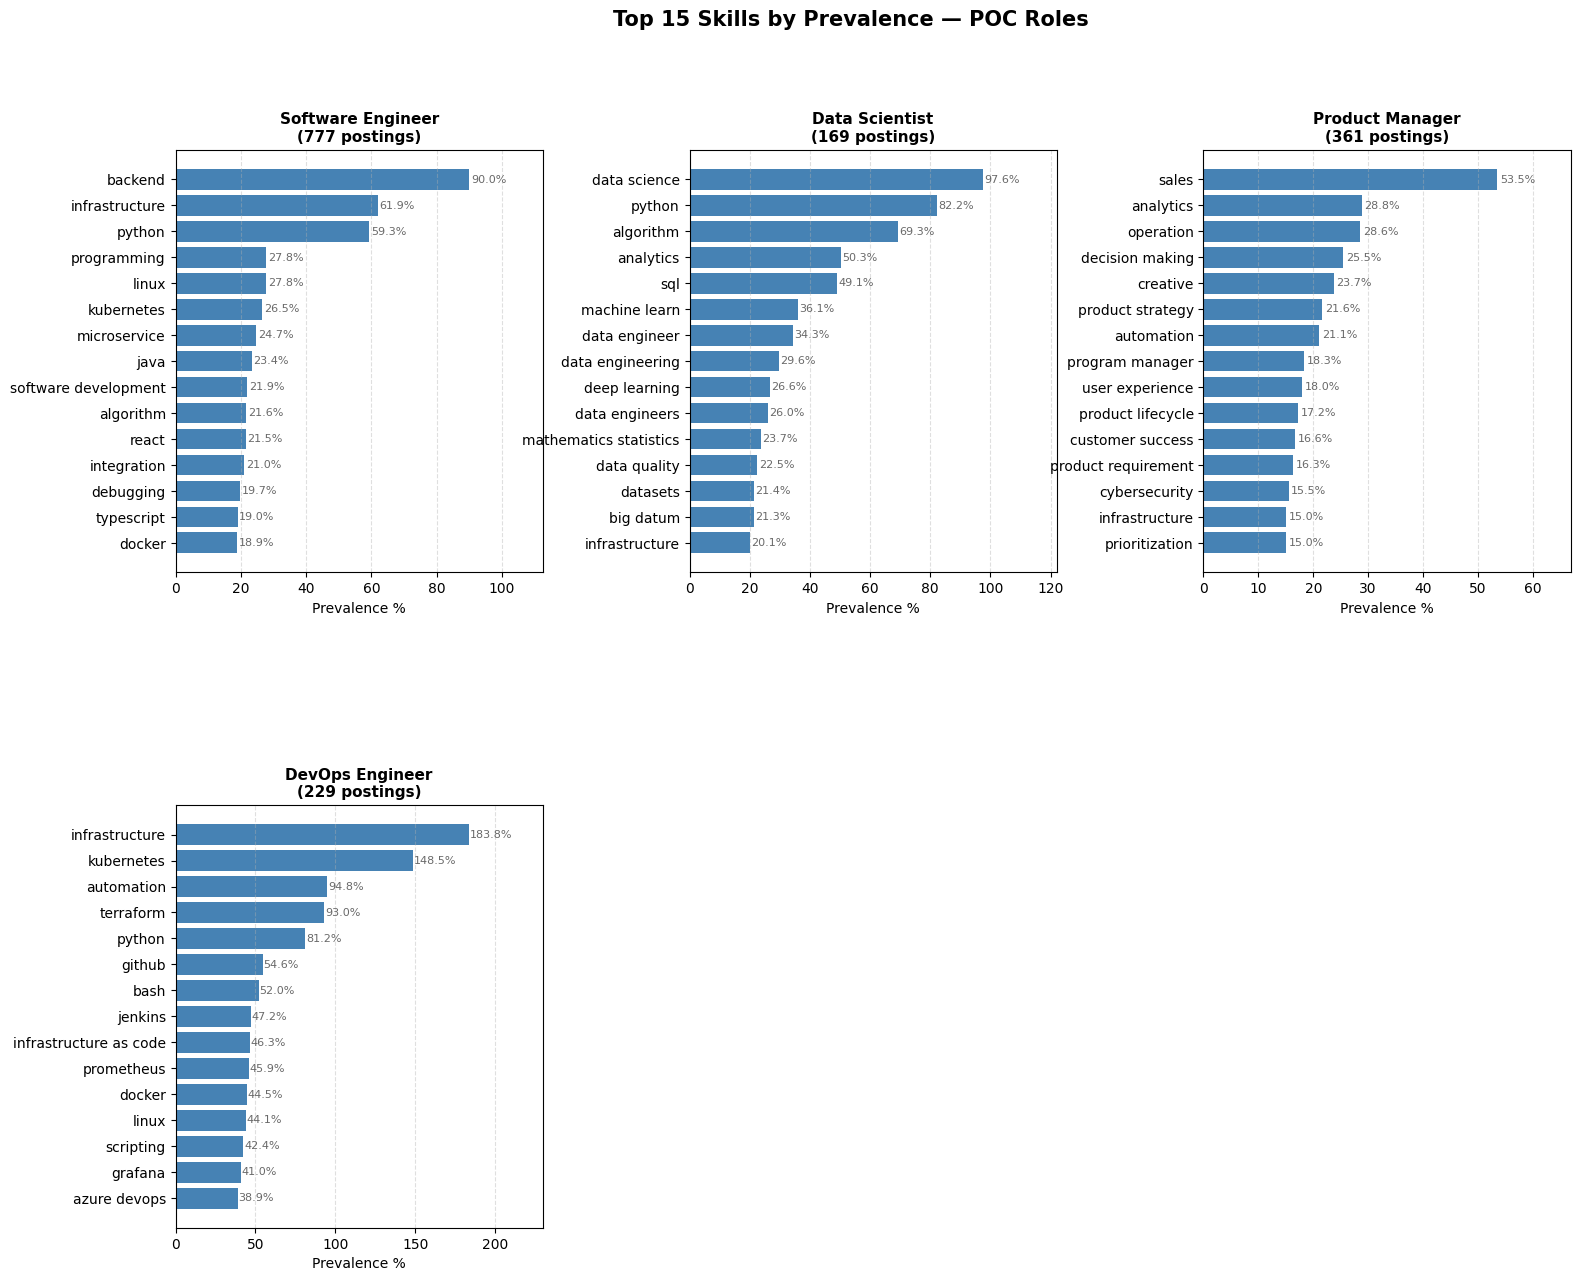

In [139]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Prevalence % visualization — top 15 skills per canonical role ─────────────
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.55, wspace=0.4)
axes = [fig.add_subplot(gs[i // 3, i % 3]) for i in range(len(POC_TITLES))]

for ax, title in zip(axes, POC_TITLES):
    n   = record_counts[title]
    top = sorted(role_skill_scores[title].items(), key=lambda x: -x[1] / n)[:15]
    skills     = [s for s, _ in top]
    prevalence = [round(sc / n * 100, 1) for _, sc in top]

    bars = ax.barh(skills[::-1], prevalence[::-1], color='steelblue')
    for bar, pct in zip(bars, prevalence[::-1]):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f'{pct}%', va='center', fontsize=8, color='dimgray')

    ax.set_title(f'{title}\n({n} postings)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Prevalence %')
    ax.set_xlim(0, max(prevalence) * 1.25)
    ax.grid(axis='x', linestyle='--', alpha=0.4)

# Hide unused subplot (5 roles, 6 slots)
fig.delaxes(fig.axes[-1])
fig.suptitle('Top 15 Skills by Prevalence — POC Roles', fontsize=15, fontweight='bold')
plt.show()

In [ ]:
import joblib
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

model_artifacts = {
    'vectorizer':     vectorizer,
    'knn_model':      knn,
    'skills':         skills_data,      # kept for backward compatibility
    'titles':         variant_labels,
    'variant_titles': variant_titles,
    'feature_matrix': feature_matrix,  # new
    'trained_at':     timestamp,
}

base = r'c:\Git\CareerLens\ds\model'

versioned_path = f'{base}\\model_{timestamp}.joblib'
joblib.dump(model_artifacts, versioned_path)

latest_path = f'{base}\\model.joblib'
joblib.dump(model_artifacts, latest_path)

print(f"Trained at : {timestamp}")
print(f"Versioned  : {versioned_path}")
print(f"Latest     : {latest_path}")
print(f"\nTop 5 skills per canonical role (prevalence-ranked):")
for title in POC_TITLES:
    idx = variant_labels.index(title)
    print(f"  {title}: {skills_data[idx][:5]}")